In [190]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
df = pd.read_csv("../data/trees-with-species-and-dimensions-urban-forest.csv") # 19 MB
df = df.drop(['Precinct', 'geolocation'], axis=1)
df = df[df['Year Planted'] > 2004]
# df['Year Planted'] = pd.to_datetime(df['Year Planted'], format='%Y')
df.head()

,CoM ID,Common Name,Scientific Name,Genus,Family,Diameter Breast Height,Year Planted,Date Planted,Age Description,Useful Life Expectency,Useful Life Expectency Value,Located in,UploadDate,CoordinateLocation,Latitude,Longitude,Easting,Northing
0,1440992,River red gum,Eucalyptus camaldulensis,Eucalyptus,Myrtaceae,NaN,2009,2009-12-14,NaN,NaN,NaN,Park,2021-01-10,"-37.789042536009, 144.94750113149306",-37.789043,144.947501,319271.37,5815606.69
1,1286119,River red gum,Eucalyptus camaldulensis,Eucalyptus,Myrtaceae,80.0,2008,2008-07-16,Mature,31-60 years,60.0,Park,2021-01-10,"-37.78989006812276, 144.9256959906416",-37.789890,144.925696,317353.24,5815470.25
2,1439848,European nettle tree,Celtis australis,Celtis,Cannabaceae,4.0,2009,2009-09-08,Juvenile,31-60 years,60.0,Street,2021-01-10,"-37.795227592098875, 144.91940533967247",-37.795228,144.919405,316812.46,5814865.65
3,1584631,Swamp Sheoak,Casuarina obesa,Casuarina,Casuarinaceae,NaN,2015,2015-06-18,NaN,NaN,NaN,Park,2021-01-10,"-37.795178798251044, 144.95235531785673",-37.795179,144.952355,319713.76,5814935.15
4,1286271,Golden Poplar,Populus x canadensis,Populus,Salicaceae,35.0,2008,2008-12-18,Semi-Mature,31-60 years,60.0,Street,2021-01-10,"-37.7904175404039, 144.92779056976474",-37.790418,144.927791,317538.99,5815415.81


In [80]:
import pandas as pd

# Example DataFrame
# Assuming df is your DataFrame with the necessary columns
# df = ...

# Group by 'Year Planted' and calculate the cumulative count of 'CoM ID'
df_count = df.groupby('Year Planted')['CoM ID'].count().cumsum().reset_index()

# Calculate the 3-year moving average
df_count['Moving Average'] = df_count['CoM ID'].rolling(window=3).mean()

# Print the DataFrame with the moving average
print(df_count)


    Year Planted  CoM ID  Moving Average
0           2005     270             NaN
1           2006    3237             NaN
2           2007    4041     2516.000000
3           2008    6317     4531.666667
4           2009    8646     6334.666667
5           2010   10720     8561.000000
6           2011   12741    10702.333333
7           2012   15765    13075.333333
8           2013   23509    17338.333333
9           2014   25400    21558.000000
10          2015   29090    25999.666667
11          2016   31465    28651.666667
12          2017   34564    31706.333333
13          2018   37130    34386.333333
14          2019   40814    37502.666667
15          2020   44432    40792.000000
16          2021   47691    44312.333333


In [87]:
df_count = df.groupby('Year Planted')['CoM ID'].count().cumsum().reset_index()
print(df_count[-6:])
df_count['Moving_avg'] = df_count['CoM ID'].rolling(window=3, closed='left').mean()
df_count

df_count.iloc[-1]['Moving_avg']

    Year Planted  CoM ID
11          2016   31465
12          2017   34564
13          2018   37130
14          2019   40814
15          2020   44432
16          2021   47691


40792.0

In [28]:
(76928-60702)/(70000+20000+(60702-45002))

0.15350993377483443

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

df_count = df[df['Year Planted'] >= 2013].groupby('Year Planted')['CoM ID'].count().cumsum().reset_index()
df_count['Moving_avg'] = df_count['CoM ID'].rolling(window=3).mean()#, closed='left').mean()
alpha = 0.8  # Smoothing parameter (0 < alpha < 1)
df_count['Exponential Smoothing'] = df_count['CoM ID'].ewm(alpha=alpha, adjust=False).mean()

# # Extrapolate moving averages for future years (2022-2040)
# for i, year in enumerate(range(2022, 2041)):
#     # Add a row for the current year with the previous year's moving average
#     print(pd.DataFrame({'Year Planted': [year], 'CoM ID': [df_count.loc[df_count['Year Planted'] == (year - 1), 'Moving_avg'].values[0]]}))
#     # df_count = pd.concat([df_count, pd.DataFrame({'Year Planted': year, 'CoM ID': df_count.loc[df_count['Year Planted'] == (year - 1), 'CoM ID'].values[0]})])
#     # Update the rolling mean including the new row
#     # df_count['Moving_avg'] = df_count['CoM ID'].rolling(window=3, closed='left').mean()
#     break

# # Print the updated DataFrame
# print(df_count)
# # Extrapolate the moving average into the future for the years 2022 to 2040
# future_years = pd.DataFrame([range(2022, 2041), 
# future_predictions = []
# print(moving_avg)
# # # Initial prediction based on the last value of the moving average
# future_predictions.append(moving_avg.iloc[-1])

# # Recursive forecasting with moving average
# for year in future_years:
#     # Concatenate the first prediction to the moving average Series
#     df_count = pd.concat([df_count, pd.Series(future_predictions[-1], index=[year])])
#     # Calculate the 5-year moving average with the new data
    # print(df_count.rolling(window=3).mean())[-1]
    # # Append the prediction for the current year
    # future_predictions.append(moving_avg)
    # break


# # Plot original data and moving average predictions
# plt.plot(df_count.index, df_count, label='Observed')
# plt.plot(moving_avg.index, moving_avg, label='5-Year Moving Average')
# plt.plot(future_years, future_predictions, label='Predicted')
# plt.xlabel('Year')
# plt.ylabel('Cumulative Trees Planted')
# plt.legend()
# plt.show()

0       NaN
1    1891.0
2    3690.0
3    2375.0
4    3099.0
5    2566.0
6    3684.0
7    3618.0
8    3259.0
Name: CoM ID, dtype: float64

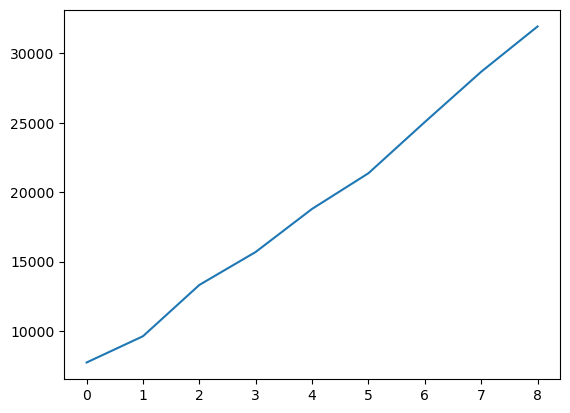

In [121]:
plt.plot(df_count['CoM ID'])

In [127]:
df_count['CoM ID'].diff().dropna()

1    1891.0
2    3690.0
3    2375.0
4    3099.0
5    2566.0
6    3684.0
7    3618.0
8    3259.0
Name: CoM ID, dtype: float64

In [149]:
df_count.iloc[-1, :]['Year Planted']

2021.0

C:\Users\agama\AppData\Local\Temp\ipykernel_7524\2569494571.py:5: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model = ExponentialSmoothing(np.asarray(df_count['CoM ID'].diff().dropna()), trend='add', seasonal=None, damped=True)


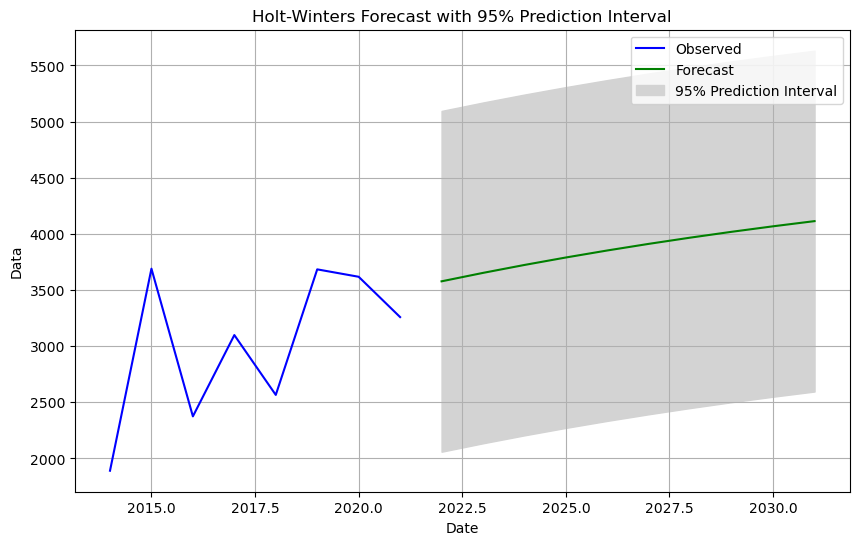

In [160]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

model = ExponentialSmoothing(np.asarray(df_count['CoM ID'].diff().dropna()), trend='add', seasonal=None, damped=True)

fit = model.fit() 

# Forecast 10 years ahead with confidence intervals
forecast = fit.forecast(steps=10)
forecast_errors = fit.resid
stderr = forecast_errors.std()

# Calculate prediction intervals (95% confidence)
prediction_intervals = pd.DataFrame(index=range(2022, 2032))
prediction_intervals['Forecast'] = forecast
prediction_intervals['Lower Bound'] = forecast - 1.96 * stderr  # 1.96 is the Z-value for 95% confidence interval
prediction_intervals['Upper Bound'] = forecast + 1.96 * stderr

# Find the index where predictions cross 42K
# crossing_index = prediction_intervals[prediction_intervals['Forecast'] > 42000].index[0]

# Plot the forecast and prediction intervals
plt.figure(figsize=(10, 6))
plt.plot(df_count['Year Planted'], df_count['CoM ID'], label='Observed', color='blue')
plt.plot(prediction_intervals.index, prediction_intervals['Forecast'], label='Forecast', color='green')
plt.fill_between(prediction_intervals.index, prediction_intervals['Lower Bound'], prediction_intervals['Upper Bound'], color='lightgray', label='95% Prediction Interval')
# plt.axvline(x=crossing_index, color='red', linestyle='--', label='Crossing 42K')
plt.xlabel('Date')
plt.ylabel('Data')
plt.title('Holt-Winters Forecast with 95% Prediction Interval')
plt.legend()
plt.grid(True)
plt.show()

In [162]:
df_count['CoM ID add'] = df_count['CoM ID'] + 90000
df_count

,Year Planted,CoM ID,Moving_avg,Exponential Smoothing,CoM ID add
0,2013,7744,NaN,7744.000000,97744
1,2014,9635,NaN,9256.800000,99635
2,2015,13325,10234.666667,12511.360000,103325
3,2016,15700,12886.666667,15062.272000,105700
4,2017,18799,15941.333333,18051.654400,108799
5,2018,21365,18621.333333,20702.330880,111365
6,2019,25049,21737.666667,24179.666176,115049
7,2020,28667,25027.000000,27769.533235,118667
8,2021,31926,28547.333333,31094.706647,121926


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_count['Moving_avg'] = df_count['CoM ID'].rolling(window=3, closed='left').mean()


# Calculate the 5-year moving average
moving_avg = df_count.rolling(window=3).mean()

# Extrapolate the moving average into the future for the years 2022 to 2040
future_years = range(2022, 2041)
future_predictions = []
print(moving_avg)
# # Initial prediction based on the last value of the moving average
future_predictions.append(moving_avg.iloc[-1])

# Recursive forecasting with moving average
for year in future_years:
    # Concatenate the first prediction to the moving average Series
    df_count = pd.concat([df_count, pd.Series(future_predictions[-1], index=[year])])
    # Calculate the 5-year moving average with the new data
    print(df_count.rolling(window=3).mean())[-1]
    # Append the prediction for the current year
    future_predictions.append(moving_avg)
    break


# # Plot original data and moving average predictions
# plt.plot(df_count.index, df_count, label='Observed')
# plt.plot(moving_avg.index, moving_avg, label='5-Year Moving Average')
# plt.plot(future_years, future_predictions, label='Predicted')
# plt.xlabel('Year')
# plt.ylabel('Cumulative Trees Planted')
# plt.legend()
# plt.show()

print(moving_avg)
future_predictions


    Year Planted        CoM ID    Moving_avg
0            NaN           NaN           NaN
1            NaN           NaN           NaN
2         2006.0   2516.000000           NaN
3         2007.0   4531.666667           NaN
4         2008.0   6334.666667           NaN
5         2009.0   8561.000000   4460.777778
6         2010.0  10702.333333   6475.777778
7         2011.0  13075.333333   8532.666667
8         2012.0  17338.333333  10779.555556
9         2013.0  21558.000000  13705.333333
10        2014.0  25999.666667  17323.888889
11        2015.0  28651.666667  21632.000000
12        2016.0  31706.333333  25403.111111
13        2017.0  34386.333333  28785.888889
14        2018.0  37502.666667  31581.444444
15        2019.0  40792.000000  34531.777778
16        2020.0  44312.333333  37560.333333
      Year Planted        CoM ID    Moving_avg  16
0              NaN           NaN           NaN NaN
1              NaN           NaN           NaN NaN
2           2006.0   2516.000000     

TypeError: 'NoneType' object is not subscriptable

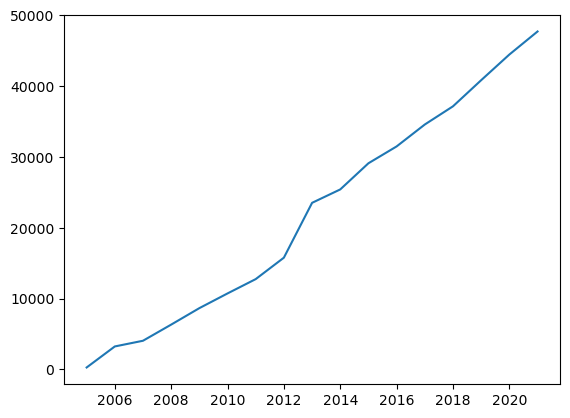

In [7]:
plt.plot(df.groupby('Year Planted')['CoM ID'].count().cumsum())

In [17]:
trees_cumsum = df.groupby('Year Planted')['CoM ID'].count().cumsum()
trees_cumsum
# 16-21 przyrost o 3.5%, w danych wychodzi ze te 3% to 10k drzew
# z tego wyliczyc ile bylo w 2016 i potem na tej podstawie mozna jacka analize


# # Get the cumulative sum of trees planted in 2016 and 2021
# trees_2016 = trees_cumsum.loc[2016]
# trees_2021 = trees_cumsum.loc[2021]

# # Calculate the percentage increase between 2016 and 2021
((trees_cumsum['2021-01-01'] - trees_cumsum['2016-01-01']) / trees_cumsum['2016-01-01']) * 100

51.56840934371524

In [ ]:
df['trees_planted'].pct_change() * 100

In [169]:
import pandas as pd
import plotly.graph_objects as go

# Sample DataFrame with Year, Category, and Percentage columns
data = {
    'Year': [2019, 2019, 2019, 2020, 2020, 2020, 2021, 2021, 2021],
    'Category': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C'],
    'Percentage': [20, 30, 50, 25, 35, 40, 30, 35, 35]
}

df = pd.DataFrame(data)

# Create a list to store the frames for animation
frames = []

# Iterate over unique years and create a frame for each year
for year in df['Year'].unique():
    df_year = df[df['Year'] == year]
    frame = go.Frame(data=[go.Treemap(
        labels=df_year['Category'],
        parents=['']*len(df_year),
        values=df_year['Percentage']
    )])
    frames.append(frame)

# Create the initial treemap plot
fig = go.Figure(go.Treemap(
    labels=df['Category'],
    parents=['']*len(df),
    values=df['Percentage']
))

# Update layout
fig.update_layout(
    title='Treemap of Percentage Changes Over Time',
    updatemenus=[{
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 1000, 'redraw': True}, 'fromcurrent': True}],
                'label': 'Play',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate', 'transition': {'duration': 0}}],
                'label': 'Pause',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 87},
        'showactive': False,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }]
)

# Add frames to animation
fig.frames = frames

# Add annotation to display the current year
fig.update_layout(
    annotations=[
        dict(
            text="Year: {}".format(df['Year'].min()),
            showarrow=False,
            xref="paper",
            yref="paper",
            x=0,
            y=1,
            xanchor='left',
            yanchor='top',
            font=dict(
                size=16
            )
        )
    ]
)

# Show the plot
fig.show()


In [192]:
import pandas as pd
import plotly.express as px

# Sample DataFrame
# data = {
#     'Latitude': [37.7749, 34.0522, 40.7128],
#     'Longitude': [-122.4194, -118.2437, -74.0060],
#     'Species': ['Oak', 'Maple', 'Pine'],
#     'Year_Planted': [2010, 2015, 2018],
#     'ULE': ['High', 'Low', 'Medium']
# }

# df = pd.DataFrame(data)

# Create a list to store DataFrames for each year
frames = []

# Iterate over unique years and create DataFrames
for year in df['Year_Planted'].unique():
    df_year = df[df['Year_Planted'] <= year].copy()
    df_year['Year'] = year
    frames.append(df_year)

# Concatenate the DataFrames
animated_df = pd.concat(frames)

# Create an animated scatter map
fig = px.scatter_mapbox(animated_df, lat="Latitude", lon="Longitude", hover_name="Species",
                        # color="ULE", color_discrete_map={'High': 'red', 'Medium': 'blue', 'Low': 'green'},
                        animation_frame="Year", animation_group="Species",
                        mapbox_style="open-street-map", zoom=3)

# Update layout
fig.update_layout(title='Interactive Map of Trees Planted Over Time with ULE',
                  mapbox=dict(center=dict(lat=37.7749, lon=-122.4194)))

# Show the map
fig.show()


KeyError: 'Year_Planted'